In [44]:
from wand.image import Image
from wand.drawing import Drawing
from wand.color import Color
from pathlib import Path
import pandas as pd

from PIL import Image as PILImage
from PIL import ImageDraw, ImageFont
import tempfile
from tqdm import tqdm
import matplotlib.pyplot as plt

In [11]:
all_ts_dir = Path('dist-s1-events_transformer_optimized-max10_processed_2026-02-12')
ts_names = [p.stem for p in all_ts_dir.glob('*/')]
ts_names[:]

['yajiang_fire_2024__2024-03-15',
 'tlacotalpan_flood_2024__2024-10-29',
 'brazzaville_flood_and_landslides_2024__2024-02-08',
 'afghanistan_flood_2024__2024-05-11',
 'attica_fire_2024__2024-08-11',
 'chile_fire_2024__2024-02-04',
 'park_fire_2024__2024-07-24',
 'southwest_france_flood_2023__2023-12-14',
 'chilcotin_river_landslide_and_flood_2024__2024-07-30',
 'hokkaido_landslides_2018__2018-09-06',
 'chiapas_fire_2024__2024-03-24',
 'cipongkor_landslides_2024__2024-03-24',
 'brazzaville_flood_and_landslides_2023__2023-12-28',
 'mai_mahiu_flood_and_landslides_2024__2024-04-29',
 'durkee_fire_2024__2024-07-17',
 'monkey_creek_fire_2024__2024-07-18',
 'papau_new_guinea_landslide_2024__2024-05-24',
 'demak_flood_2024__2024-03-15',
 'tuscany_flood_2023__2023-11-02',
 'bangladesh_coastal_flood_2024__2024-07-08',
 'smokehouse_creek_fire_2024__2024-02-26',
 'porto_alegre_flood_2024__2024-05-28',
 'los_angeles_fires_2025__2025-01-04',
 'bioko_fire_2024__2024-02-07']

In [25]:
event_name = 'los_angeles_fires_2025__2025-01-04'
KEY = '11SLT_palisades_fire_2025'

In [28]:
ts_dir = all_ts_dir / event_name
ts_dir.exists()

True

In [39]:
status_files = sorted(list(ts_dir.rglob('*GEN-DIST-STATUS.tif')))
status_files[:3]

[PosixPath('dist-s1-events_transformer_optimized-max10_processed_2026-02-12/los_angeles_fires_2025__2025-01-04/OPERA_L3_DIST-ALERT-S1_T11SLT_20241209T015842Z_20260213T001107Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T11SLT_20241209T015842Z_20260213T001107Z_S1A_30_v0.1_GEN-DIST-STATUS.tif'),
 PosixPath('dist-s1-events_transformer_optimized-max10_processed_2026-02-12/los_angeles_fires_2025__2025-01-04/OPERA_L3_DIST-ALERT-S1_T11SLT_20241209T140101Z_20260213T000228Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T11SLT_20241209T140101Z_20260213T000228Z_S1A_30_v0.1_GEN-DIST-STATUS.tif'),
 PosixPath('dist-s1-events_transformer_optimized-max10_processed_2026-02-12/los_angeles_fires_2025__2025-01-04/OPERA_L3_DIST-ALERT-S1_T11SLT_20241216T015033Z_20260213T000044Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T11SLT_20241216T015033Z_20260213T000044Z_S1A_30_v0.1_GEN-DIST-STATUS.tif')]

In [53]:
def get_date_from_dist_status_file(path: Path | str):
    path = Path(path)
    name = path.stem
    date_str = name.split('_')[4]
    ts = pd.Timestamp(date_str)
    return ts

dist_ts = [get_date_from_dist_status_file(p) for p in status_files]
dist_ts[:3]


[Timestamp('2024-12-09 01:58:42+0000', tz='UTC'),
 Timestamp('2024-12-09 14:01:01+0000', tz='UTC'),
 Timestamp('2024-12-16 01:50:33+0000', tz='UTC')]

In [56]:
dist_ts_str = [ts.strftime('%Y/%m/%d %H:%M') for ts in dist_ts]
dist_ts_str[:3]


['2024/12/09 01:58', '2024/12/09 14:01', '2024/12/16 01:50']

In [40]:
from dem_stitcher.rio_window import read_raster_from_window

In [41]:
from bounds_config import BOUNDS

bounds = BOUNDS[KEY]

In [47]:
arrs = [read_raster_from_window(p, bounds)[0] for p in tqdm(status_files)]

100%|██████████| 30/30 [00:00<00:00, 196.58it/s]


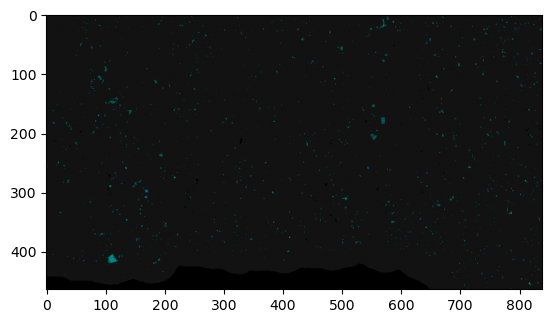

In [52]:
from dist_s1.dist_plot import get_dist_s1_mpl_cmap
dist_cmap, dist_norm = get_dist_s1_mpl_cmap()
plt.imshow(arrs[0][0], cmap=dist_cmap, norm=dist_norm)

In [55]:
png_dir = Path(f'pngs/events/{event_name}')
png_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
for i, arr in enumerate(tqdm(arrs)):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(arr[0, ...], cmap=dist_cmap, norm=dist_norm)
    ax.axis('off')
    ax.text(0.95, 0.95, dist_ts_str[i], transform=ax.transAxes,ha='right', va='top', fontsize=15, c='white')
    plt.savefig(png_dir / f'{KEY}_{i}.png', bbox_inches='tight', pad_inches=0)
    plt.close()
    


100%|██████████| 30/30 [00:02<00:00, 10.23it/s]


In [78]:
png_paths = sorted(list(png_dir.rglob('*.png')))
png_paths[:3]

[PosixPath('pngs/events/los_angeles_fires_2025__2025-01-04/los_angeles_fires_2025__2025-01-04_0.png'),
 PosixPath('pngs/events/los_angeles_fires_2025__2025-01-04/los_angeles_fires_2025__2025-01-04_1.png'),
 PosixPath('pngs/events/los_angeles_fires_2025__2025-01-04/los_angeles_fires_2025__2025-01-04_10.png')]

In [79]:
def pngs_to_gif(png_files, output_gif):
    with Image() as gif:
        for f in png_files:
            with Image(filename=f) as frame:
                frame.delay = 100
                gif.sequence.append(frame)
        for frame in gif.sequence:
            frame.dispose = 'background'
        gif.type = 'optimize'
        gif.save(filename=output_gif)


def create_gif_with_text(png_files, output_path, text_list):
    with tempfile.TemporaryDirectory() as tmpdir:
        modified_files = []
        
        for i, (png_file, text) in enumerate(zip(png_files, text_list)):
            img = PILImage.open(png_file)
            img = img.convert('RGBA')
            draw = ImageDraw.Draw(img)
            
            font = ImageFont.truetype("Times New Roman", 150)
            
            draw.text((100, 100), text, font=font, fill=(255, 255, 255, 255), stroke_width=5, stroke_fill=(0, 0, 0, 255))
            
            temp_file = Path(tmpdir) / f'temp_frame_{i}.png'
            img.save(temp_file)
            modified_files.append(temp_file)
            img.close()
        
        with Image() as gif:
            for modified_file in modified_files:
                with Image(filename=str(modified_file)) as img:
                    img.delay = 100
                    gif.sequence.append(img)
            
            gif.type = 'optimize'
            gif.save(filename=output_path)

In [80]:
out_gif = f'{KEY}__status.gif'

In [81]:
pngs_to_gif(png_paths, out_gif) 